# Study 3: Platform as facilitator of sentiment and idea flow 
# Part 1: sentiment flows

## Libraries

In [ ]:
import os, zipfile, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import fiona
from shapely.geometry import shape, Point
from shapely.strtree import STRtree
import geopandas as gpd
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import networkx as nx


## Get the official municipality for each review

In [46]:
# -----------------------
# 1) Load boundary polygons from the ZIP shapefile
# -----------------------
zip_path = "PA Municipality Boundaries_20260120.zip"
extract_dir = "pa_muni_bounds"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

shp_path = glob.glob(os.path.join(extract_dir, "**", "*.shp"), recursive=True)[0]

# Field names (from your shapefile attributes)
name_field = "municipal1"
id_field   = "municipal_"   # <-- adjust if needed after seeing available fields below

polys = []
names = []
ids   = []

with fiona.open(shp_path) as src:
    print("Available fields:", list(src.schema["properties"].keys()))
    for feat in src:
        geom = feat["geometry"]
        if geom is None:
            continue
        nm  = feat["properties"].get(name_field)
        mid = feat["properties"].get(id_field)
        if nm is None:
            continue
        polys.append(shape(geom))
        names.append(str(nm).strip())
        ids.append(mid)

polys_arr = np.array(polys, dtype=object)
names_arr = np.array(names)
ids_arr   = np.array(ids)

tree = STRtree(polys_arr)

def muni_from_point(lon, lat):
    if pd.isna(lon) or pd.isna(lat):
        return np.nan, np.nan
    pt = Point(float(lon), float(lat))
    for idx in tree.query(pt):
        if polys_arr[idx].contains(pt):
            return names_arr[idx], ids_arr[idx]
    return np.nan, np.nan

# -----------------------
# Apply to your reviews
# -----------------------
reviews = pd.read_csv("PA_brewpub_reviews.csv")
reviews["latitude"]  = pd.to_numeric(reviews["latitude"], errors="coerce")
reviews["longitude"] = pd.to_numeric(reviews["longitude"], errors="coerce")

results = reviews.apply(
    lambda r: muni_from_point(r["longitude"], r["latitude"]),
    axis=1
)
reviews["municipality_from_shape"] = results.apply(lambda x: x[0])
reviews["municipality_id"]         = results.apply(lambda x: x[1])


Available fields: ['mslink', 'county', 'municipal_', 'municipal1', 'fips_mun_c', 'fed_aid_ur', 'fips_count', 'fips_area_', 'fips_name', 'fips_sq_mi', 'fips_mun_p', 'fed_id_num', 'class_of_m', 'date_gis_u', 'time_gis_u', 'date_gis_g', 'time_gis_g', 'gpid', 'geometry_l', 'geometry_a']


# Sentiment flows

Map inter-municipal transitions for users who travelled to 10 or more municipalities for their Pennsylvania brewpub reviews. 

In [47]:
reviews = pd.read_csv("PA_brewpub_reviews.csv").drop_duplicates()

In [48]:
# -----------------------
# CONFIG
# -----------------------

MIN_UNIQUE_MUNIS = 10  # <-- set your threshold here

MIN_EDGE_WEIGHT = 30
TOP_N_EDGES = None  # set None for all

PAIR_RAD = 0.35
UNIDIR_RAD = 0.10
EDGE_COLOR = "red"
EDGE_ALPHA = 0.75
ARROW_SCALE = 10

DRAW_POLYGONS = True
POLY_EDGE_COLOR = "lightgray"
POLY_LINEWIDTH = 0.6

NODE_SIZE = 35
LABEL_TOP_N_NODES = 10
LABEL_FONTSIZE = 7

In [49]:
# -----------------------
# HELPERS
# -----------------------
def stable_pair_sign(a, b) -> int:
    s = str(a) + "||" + str(b)
    return 1 if (sum(ord(c) for c in s) % 2 == 0) else -1


def draw_arc_arrow(ax, x1, y1, x2, y2, lw, rad, color="red", alpha=0.75):
    ax.add_patch(FancyArrowPatch(
        (float(x1), float(y1)), (float(x2), float(y2)),
        arrowstyle='-|>',
        mutation_scale=ARROW_SCALE,
        linewidth=float(lw),
        alpha=alpha,
        color=color,
        connectionstyle=f"arc3,rad={float(rad)}"
    ))


def guess_datetime_columns(df: pd.DataFrame):
    date = next((c for c in df.columns if c.lower() == "review_date"), None)
    time = next((c for c in df.columns if c.lower() == "review_time"), None)
    if date is None:
        date_like = [c for c in df.columns if "date" in c.lower()]
        date = date_like[0] if date_like else None
    return date, time

In [50]:
# -----------------------
# CREATE GEO DATAFRAME FOR MAPPING
# -----------------------

reviews['latitude'] = pd.to_numeric(reviews['latitude'], errors="coerce")
reviews['longitude'] = pd.to_numeric(reviews['longitude'], errors="coerce")

pts = reviews.dropna(subset=['latitude', 'longitude']).copy()

rev_gdf = gpd.GeoDataFrame(
    pts,
    geometry=gpd.points_from_xy(pts['longitude'], pts['latitude']),
    crs="EPSG:4326"
)

In [51]:
date_col, time_col = guess_datetime_columns(reviews)

In [52]:
# -----------------------
# LOAD MUNICIPAL SHAPES + BUILD UNIQUE ID
# -----------------------
muni_gdf = gpd.read_file(f"zip://{"PA Municipality Boundaries_20260120.zip"}")

# Validate required fields
need = ["county", "municipal_", "municipal1", "geometry"]
missing = [c for c in need if c not in muni_gdf.columns]
if missing:
    raise ValueError(f"Shapefile is missing columns: {missing}\nAvailable columns: {list(muni_gdf.columns)}")

# Ensure CRS is WGS84 lon/lat
if muni_gdf.crs is None:
    muni_gdf = muni_gdf.set_crs(epsg=4326)
else:
    muni_gdf = muni_gdf.to_crs(epsg=4326)

# Build unique ID from municipal_ + county
muni_gdf["muni_id"] = (
    muni_gdf["municipal_"].astype(str).str.strip().str.upper()
    + " | " +
    muni_gdf["county"].astype(str).str.strip().str.upper()
)

# Compute centroids in a metric CRS (3857), then back to lon/lat
muni_3857 = muni_gdf.to_crs(3857)
cent_4326 = muni_3857.geometry.centroid.to_crs(4326)

centroids = pd.DataFrame({
    "muni_id": muni_gdf["muni_id"].astype(str),
    "municipality_name": muni_gdf["municipal1"].astype(str),   # pretty label
    "lon": cent_4326.x.values,
    "lat": cent_4326.y.values,
}).set_index("muni_id")

In [53]:
# -----------------------
# Spatial join: point-in-polygon
# -----------------------
joined = gpd.sjoin(
    rev_gdf,
    muni_gdf[["muni_id", "municipal1", "geometry"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

joined = joined.dropna(subset=["muni_id"]).copy()
joined["muni_id"] = joined["muni_id"].astype(str)

print("Reviews total:", len(reviews))
print("Reviews with lat/lon:", len(pts))
print("Reviews matched to municipality:", len(joined))

Reviews total: 92706
Reviews with lat/lon: 92706
Reviews matched to municipality: 92706


In [54]:
# -----------------------
# process dates and times
# -----------------------
joined[date_col] = pd.to_datetime(joined[date_col], errors="coerce")
sort_cols = ["review_user_id", date_col]
if time_col and time_col in joined.columns:
    sort_cols.append(time_col)
joined = joined.sort_values(sort_cols, na_position="last")

### Summarize overall transitions

In [73]:
# -----------------------
# Tally overall transitions (all users)
# -----------------------
all_pairs = []
for uid, grp in joined.groupby("review_user_id", sort=False):
    seq = grp["muni_id"].astype(str).tolist()
    if len(seq) > 1:
        all_pairs.extend(zip(seq[:-1], seq[1:]))

edges_all = pd.DataFrame(all_pairs, columns=["from_id", "to_id"])
edges_all = edges_all[edges_all["from_id"] != edges_all["to_id"]].copy()

edge_counts_all = (
    edges_all
    .groupby(["from_id", "to_id"])
    .size()
    .reset_index(name="w")
    .sort_values("w", ascending=False)
    .reset_index(drop=True)
)

# Attach readable names
edge_counts_all["from_name"] = edge_counts_all["from_id"].map(centroids["municipality_name"])
edge_counts_all["to_name"]   = edge_counts_all["to_id"].map(centroids["municipality_name"])

print(f"Total directed edges:     {len(edge_counts_all):,}")
print(f"Total transition events:  {edge_counts_all['w'].sum():,}")
print(f"Municipalities involved:  {pd.unique(edge_counts_all[['from_id','to_id']].values.ravel()).size:,}")
print()
print("--- Top 20 most frequent transitions ---")
print(
    edge_counts_all[["from_name", "to_name", "w"]]
    .head(20)
    .to_string(index=False)
)
print()
print("--- Weight distribution ---")
print(edge_counts_all["w"].describe().round(2))


Total directed edges:     4,157
Total transition events:  12,943
Municipalities involved:  153

--- Top 20 most frequent transitions ---
     from_name        to_name   w
   SPRINGFIELD   PHILADELPHIA 152
  PHILADELPHIA UPPER MORELAND 130
UPPER MORELAND   PHILADELPHIA 117
  PHILADELPHIA    SPRINGFIELD 104
   DOWNINGTOWN WEST WHITELAND  84
    MIDDLETOWN   PHILADELPHIA  82
  PHILADELPHIA     MIDDLETOWN  71
     LANCASTER        MANHEIM  69
     SWISSVALE     PITTSBURGH  60
  LOWER MERION   PHILADELPHIA  57
  PHILADELPHIA   LOWER MERION  50
        LITITZ      LANCASTER  49
WEST WHITELAND    DOWNINGTOWN  49
    PITTSBURGH      SWISSVALE  48
     MILLCREEK           ERIE  44
       MANHEIM      LANCASTER  43
       BERWICK          SCOTT  42
CASTLE SHANNON     PITTSBURGH  41
       HARMONY          ADAMS  41
   DOWNINGTOWN   WEST CHESTER  40

--- Weight distribution ---
count    4157.00
mean        3.11
std         6.56
min         1.00
25%         1.00
50%         1.00
75%         3.00
m

In [74]:

G_all = nx.DiGraph()
G_all.add_weighted_edges_from(
    edge_counts_all[["from_id", "to_id", "w"]].itertuples(index=False)
)

print(f"Nodes: {G_all.number_of_nodes():,}")
print(f"Edges: {G_all.number_of_edges():,}")
print()
print("Weakly connected: ", nx.is_weakly_connected(G_all))
print("Strongly connected:", nx.is_strongly_connected(G_all))
print()
print(f"Weak components:   {nx.number_weakly_connected_components(G_all):,}")
print(f"Strong components: {nx.number_strongly_connected_components(G_all):,}")


Nodes: 153
Edges: 4,157

Weakly connected:  True
Strongly connected: False

Weak components:   1
Strong components: 6


### Map transitions for select subset of users

In [55]:
# -----------------------
# select subset of users
# -----------------------
MIN_UNIQUE_MUNIS = 10  # <-- set your threshold here

# unique municipalities visited per user
user_uniques = joined.groupby("review_user_id")["muni_id"].nunique()

# selected users
selected_users = user_uniques[user_uniques >= MIN_UNIQUE_MUNIS].index
print("Selected users:", len(selected_users))

Selected users: 36


In [56]:
# subset reviews to selected users
sel = joined[joined["review_user_id"].isin(selected_users)].copy()

# ensure time ordering (use your same date/time columns)
sel = sel.sort_values(["review_user_id", "review_date"], na_position="last")

# build directed transitions from muni_id sequences
pairs = []
for uid, grp in sel.groupby("review_user_id", sort=False):
    seq = grp["muni_id"].astype(str).tolist()
    if len(seq) > 1:
        pairs.extend(zip(seq[:-1], seq[1:]))

edges_sel = pd.DataFrame(pairs, columns=["from_id", "to_id"])
edges_sel = edges_sel[edges_sel["from_id"] != edges_sel["to_id"]].copy()

# aggregate counts (optional but recommended for visibility)
edge_counts_sel = edges_sel.groupby(["from_id", "to_id"]).size().reset_index(name="w")
edge_counts_sel = edge_counts_sel.sort_values("w", ascending=False)

print("Directed edges from selected users:", len(edge_counts_sel))

Directed edges from selected users: 447


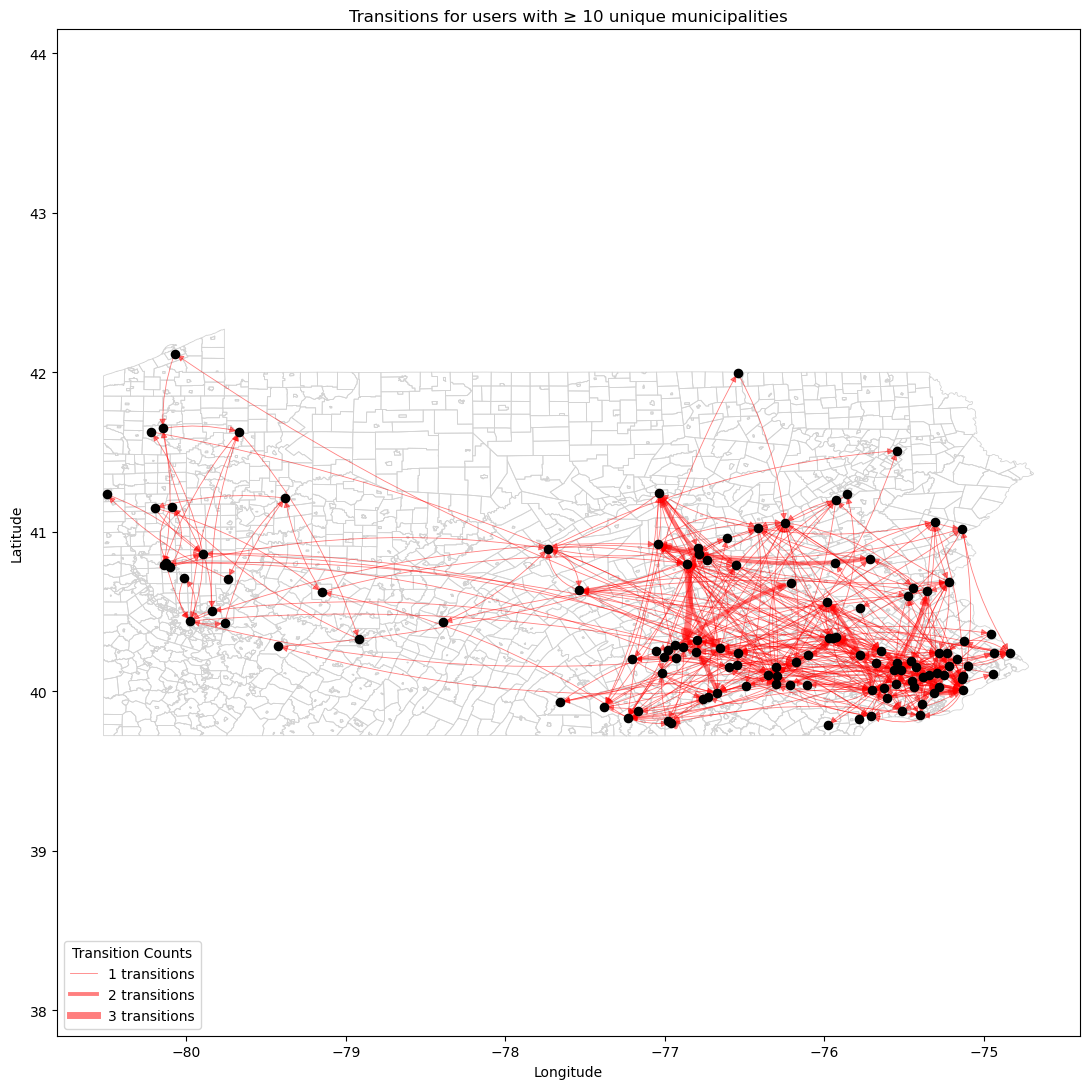

In [72]:
fig, ax = plt.subplots(figsize=(11, 11))

# polygons
muni_gdf.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.6, zorder=1)

# linewidth scaling by weight
w = edge_counts_sel["w"].to_numpy(float)
lws = 0.6 + 4.4 * (w - w.min()) / (w.max() - w.min() + 1e-9) if len(w) else np.array([])

# curvature assignment (same “cycle lens” rule)
edge_set_sel = set(zip(edge_counts_sel["from_id"], edge_counts_sel["to_id"]))

def edge_rad(fid, tid):
    has_rev = (tid, fid) in edge_set_sel
    u, v = sorted((fid, tid))
    base = stable_pair_sign(u, v)
    if has_rev:
        return base * PAIR_RAD if fid == u else base * PAIR_RAD
    return base * UNIDIR_RAD

edge_counts_sel["rad"] = [edge_rad(f, t) for f, t in zip(edge_counts_sel["from_id"], edge_counts_sel["to_id"])]

# draw edges
for (_, r), lw in zip(edge_counts_sel.iterrows(), lws):
    if r["from_id"] not in centroids.index or r["to_id"] not in centroids.index:
        continue
    A = centroids.loc[r["from_id"]]
    B = centroids.loc[r["to_id"]]
    draw_arc_arrow(ax, A["lon"], A["lat"], B["lon"], B["lat"], lw, r["rad"], color="red", alpha=0.5)

# nodes
used_nodes = pd.Index(pd.unique(edge_counts_sel[["from_id", "to_id"]].values.ravel("K")))
nodes = centroids.loc[used_nodes]
ax.scatter(nodes["lon"], nodes["lat"], s=35, color="black", zorder=5)

ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Transitions for users with ≥ {MIN_UNIQUE_MUNIS} unique municipalities")
plt.tight_layout()


from matplotlib.lines import Line2D
import numpy as np

# Pick 3 representative integer flow values (you can change these)
# The simplest choice is: minimum, median, maximum
weights = edge_counts_sel["w"].to_numpy()

w_min = int(weights.min())
w_med = 2
w_max = int(weights.max())

# Use the same mapping from weight -> linewidth
def weight_to_lw(w_value):
    return 0.6 + 4.4 * (w_value - weights.min()) / (weights.max() - weights.min() + 1e-9)

lw_min = weight_to_lw(w_min)
lw_med = weight_to_lw(w_med)
lw_max = weight_to_lw(w_max)

# Build legend handles
legend_lines = [
    Line2D([0], [0], color="red", alpha=0.5, lw=lw_min, label=f"{w_min} transitions"),
    Line2D([0], [0], color="red", alpha=0.5, lw=lw_med, label=f"{w_med} transitions"),
    Line2D([0], [0], color="red", alpha=0.5, lw=lw_max, label=f"{w_max} transitions"),
]

# Add legend
ax.legend(
    handles=legend_lines,
    title="Transition Counts",
    loc="lower left",
    frameon=True
)

plt.savefig("top_traveller_transitions.png")
plt.show()

In [58]:
used_nodes

Index(['404 | 54', '404 | 21', '103 | 66', '408 | 36', '103 | 23', '401 | 46',
       '224 | 46', '413 | 15', '227 | 66', '302 | 49',
       ...
       '223 | 32', '254 | 15', '236 | 15', '234 | 15', '230 | 20', '226 | 43',
       '225 | 36', '103 | 21', '401 | 35', '110 | 46'],
      dtype='object', length=122)

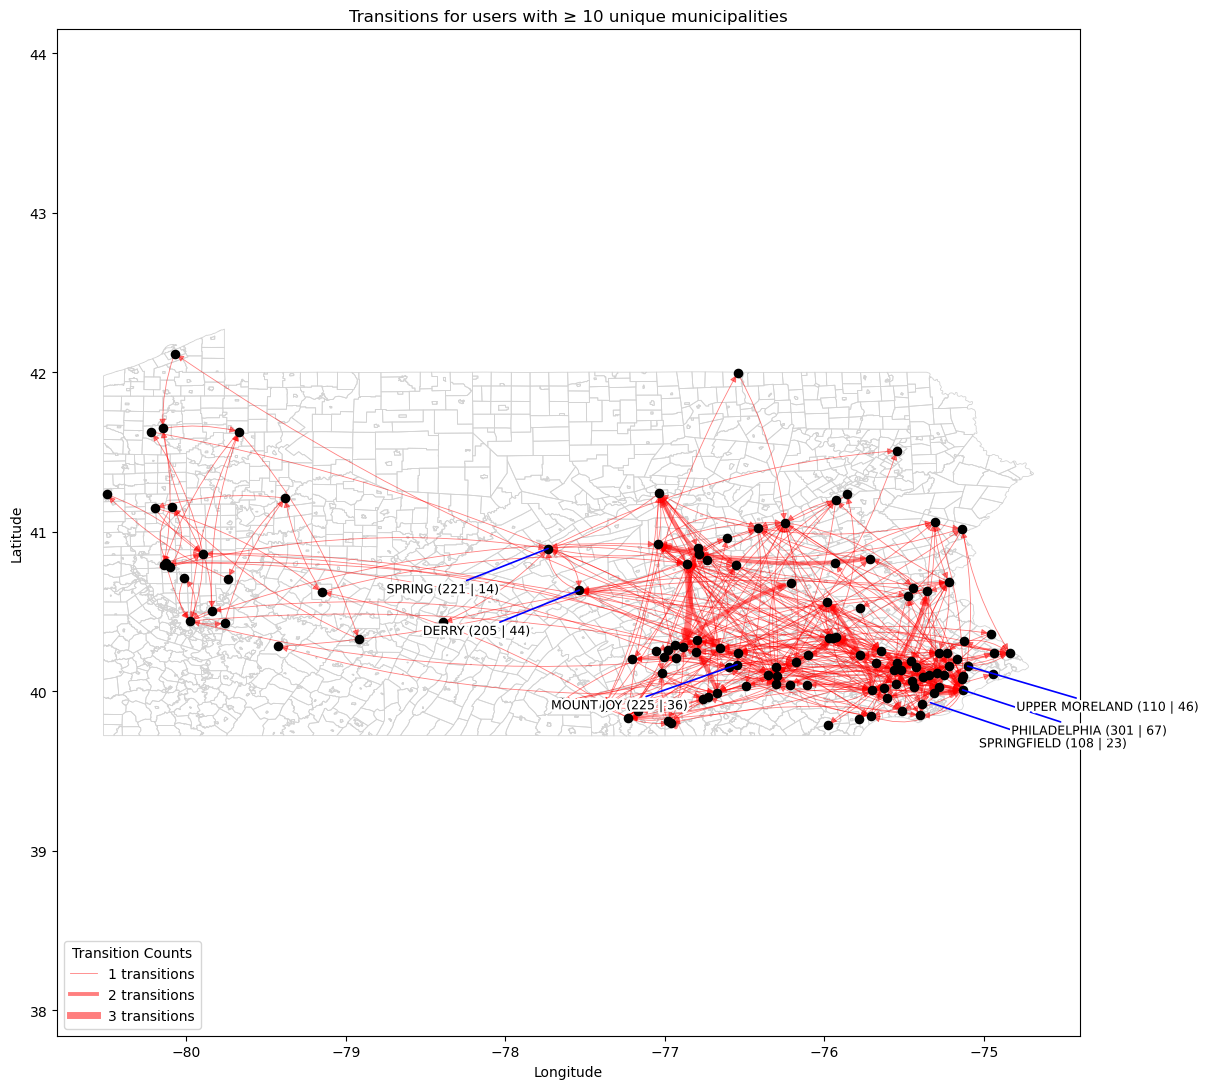

In [59]:
fig, ax = plt.subplots(figsize=(11, 11))

# polygons
muni_gdf.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.6, zorder=1)

# linewidth scaling by weight
w = edge_counts_sel["w"].to_numpy(float)
lws = 0.6 + 4.4 * (w - w.min()) / (w.max() - w.min() + 1e-9) if len(w) else np.array([])

# curvature assignment (same “cycle lens” rule)
edge_set_sel = set(zip(edge_counts_sel["from_id"], edge_counts_sel["to_id"]))

def edge_rad(fid, tid):
    has_rev = (tid, fid) in edge_set_sel
    u, v = sorted((fid, tid))
    base = stable_pair_sign(u, v)
    if has_rev:
        return base * PAIR_RAD if fid == u else base * PAIR_RAD
    return base * UNIDIR_RAD

edge_counts_sel["rad"] = [edge_rad(f, t) for f, t in zip(edge_counts_sel["from_id"], edge_counts_sel["to_id"])]

# draw edges
for (_, r), lw in zip(edge_counts_sel.iterrows(), lws):
    if r["from_id"] not in centroids.index or r["to_id"] not in centroids.index:
        continue
    A = centroids.loc[r["from_id"]]
    B = centroids.loc[r["to_id"]]
    draw_arc_arrow(ax, A["lon"], A["lat"], B["lon"], B["lat"], lw, r["rad"], color="red", alpha=0.5)

# nodes
used_nodes = pd.Index(pd.unique(edge_counts_sel[["from_id", "to_id"]].values.ravel("K")))
nodes = centroids.loc[used_nodes]
ax.scatter(nodes["lon"], nodes["lat"], s=35, color="black", zorder=5)

ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Transitions for users with ≥ {MIN_UNIQUE_MUNIS} unique municipalities")
plt.tight_layout()




# Pick 3 representative integer flow values (you can change these)
# The simplest choice is: minimum, median, maximum
weights = edge_counts_sel["w"].to_numpy()

w_min = int(weights.min())
w_med = 2
w_max = int(weights.max())

# Use the same mapping from weight -> linewidth
def weight_to_lw(w_value):
    return 0.6 + 4.4 * (w_value - weights.min()) / (weights.max() - weights.min() + 1e-9)

lw_min = weight_to_lw(w_min)
lw_med = weight_to_lw(w_med)
lw_max = weight_to_lw(w_max)

# Build legend handles
legend_lines = [
    Line2D([0], [0], color="red", alpha=0.5, lw=lw_min, label=f"{w_min} transitions"),
    Line2D([0], [0], color="red", alpha=0.5, lw=lw_med, label=f"{w_med} transitions"),
    Line2D([0], [0], color="red", alpha=0.5, lw=lw_max, label=f"{w_max} transitions"),
]

# Add legend
ax.legend(
    handles=legend_lines,
    title="Transition Counts",
    loc="lower left",
    frameon=True
)


# --- Targets: muni_id -> label text ---
targets = {
    "108 | 23": "SPRINGFIELD",
    "301 | 67": "PHILADELPHIA",
    "110 | 46": "UPPER MORELAND",
    "221 | 14": "SPRING",
    "205 | 44": "DERRY",
    "225 | 36": "MOUNT JOY"
}

# Optional: manually chosen label offsets (in screen points) so labels don’t sit on top of nodes
# Tweak these numbers as you like.
offsets_pts = {
    "108 | 23": (35, -25),
    "301 | 67": (35, -25),
    "110 | 46": (35, -25),
    "221 | 14": (-35, -25),
    "205 | 44": (-35, -25),
    "225 | 36": (-35, -25)
}

# Text outline (stroke) settings
outline_effect = [pe.Stroke(linewidth=3.5, foreground="white"), pe.Normal()]

for muni_id, label in targets.items():
    if muni_id not in centroids.index:
        print(f"WARNING: muni_id not found in centroids: {muni_id}")
        continue

    lon = float(centroids.loc[muni_id, "lon"])
    lat = float(centroids.loc[muni_id, "lat"])

    dx, dy = offsets_pts.get(muni_id, (25, 20))  # default offset if not specified

    ax.annotate(
        f"{label} ({muni_id})",
        xy=(lon, lat),                    # point being labeled
        xytext=(dx, dy),                  # offset in points
        textcoords="offset points",
        ha="left" if dx >= 0 else "right",
        va="bottom" if dy >= 0 else "top",
        fontsize=9,
        zorder=20,
        path_effects=outline_effect,      # outlined text
        arrowprops=dict(                  # leader line
            arrowstyle="-",               # line only (no arrow head)
            lw=1.2,
            color="blue",
            shrinkA=0,
            shrinkB=0,
            connectionstyle="arc3,rad=0.0"  # straight leader line
        ),
    )


plt.show()

## See if subgraph is at least weakly connected

In [ ]:

G = nx.DiGraph()
G.add_weighted_edges_from(
    edge_counts_sel[["from_id", "to_id", "w"]].itertuples(index=False)
)

print("Weakly connected:", nx.is_weakly_connected(G))
print("Strongly connected:", nx.is_strongly_connected(G))

# If not connected, see how many components there are:
n_weak = nx.number_weakly_connected_components(G)
n_strong = nx.number_strongly_connected_components(G)
print(f"Weak components: {n_weak}, Strong components: {n_strong}")


Weakly connected: True
Strongly connected: False
Weak components: 1, Strong components: 8


## Tally user stats

In [61]:
# Ensure boolean
joined["has_response"] = joined["has_response"].astype(bool)


# Tally by user
tally_df = (
    joined
    .groupby("review_user_id")
    .agg(
        num_reviews=("review_user_id", "size"),
        num_responses=("has_response", "sum"),
        unique_municipalities=("muni_id", lambda x: x.nunique(dropna=True))
    )
    .reset_index()
)

tally_df = (
    tally_df
    .sort_values(
        by=["unique_municipalities", "num_reviews"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

In [62]:
# view the status of the top 10 users who visiteded the most municipalities to review brewpubs
tally_df.head(10)

,review_user_id,num_reviews,num_responses,unique_municipalities
0,100761017229872623295,47,8,40
1,108381609537697399047,40,6,31
2,103811505687982530294,17,1,15
3,108974402442719254551,17,4,15
4,110738454186479599315,17,3,15
5,103181905061040953546,15,1,15
6,111295982738784490568,15,2,15
7,111468092806224451086,15,1,15
8,108403622854967389100,14,3,13
9,112415617591068643733,14,2,13


## Find the municipality coverage of the top 100 most prolific brewpub reviewers in Pennsylvania

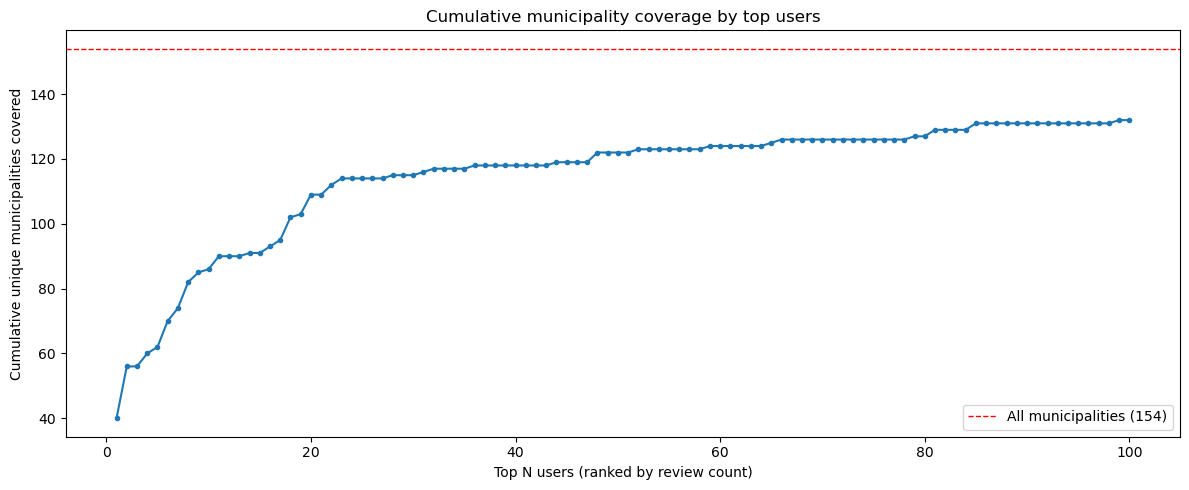

In [63]:
# Map each user to the set of municipalities they reviewed
user_munis = (
    joined.dropna(subset=["muni_id"])
    .groupby("review_user_id")["muni_id"]
    .apply(set)
    .to_dict()
)

# Walk users in descending review-count order, accumulating unique municipalities
top_users = tally_df.sort_values("num_reviews", ascending=False).reset_index(drop=True)

seen_munis = set()
cumulative_munis = []
for uid in top_users["review_user_id"]:
    seen_munis.update(user_munis.get(uid, set()))
    cumulative_munis.append(len(seen_munis))

X = 100  # how many top users to show
x_vals = range(1, min(X, len(cumulative_munis)) + 1)
y_vals = cumulative_munis[:X]

total_munis = joined["muni_id"].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(x_vals), y_vals, marker="o", markersize=3, linewidth=1.5)
ax.axhline(total_munis, color="red", linestyle="--", linewidth=1,
           label=f"All municipalities ({total_munis})")
ax.set_xlabel("Top N users (ranked by review count)")
ax.set_ylabel("Cumulative unique municipalities covered")
ax.set_title("Cumulative municipality coverage by top users")
ax.legend()
plt.tight_layout()
plt.show()

In [64]:
y_vals[99] / joined['muni_id'].nunique()

0.8571428571428571

85% of the possible municipalities are covered by the top 100 most prolific brewpub reviewers.

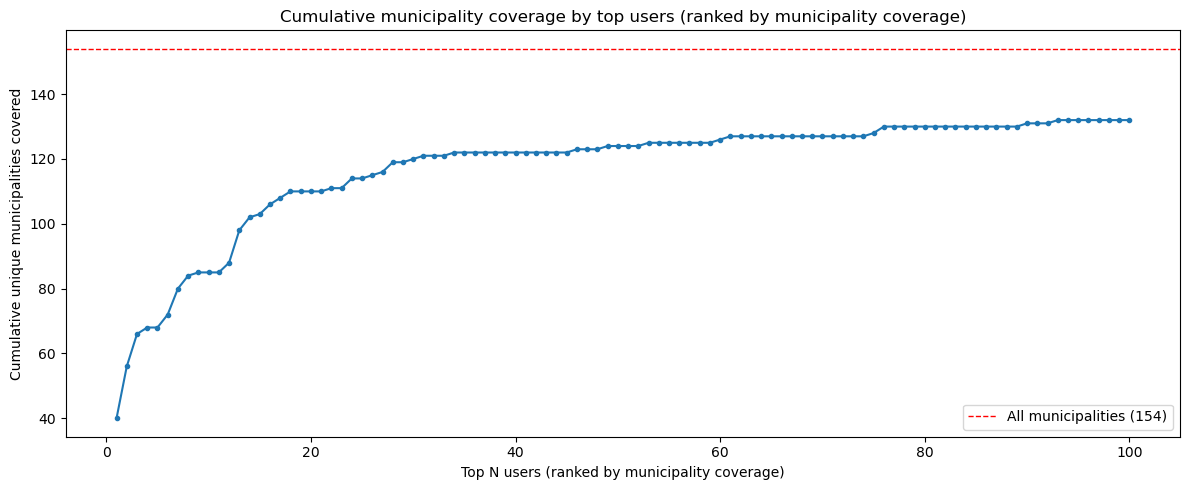

In [65]:
# Map each user to the set of municipalities they reviewed
user_munis = (
    joined.dropna(subset=["muni_id"])
    .groupby("review_user_id")["muni_id"]
    .apply(set)
    .to_dict()
)

# Walk users in descending municipality-coverage order, accumulating unique municipalities
top_users = tally_df.sort_values("unique_municipalities", ascending=False).reset_index(drop=True)

seen_munis = set()
cumulative_munis = []
for uid in top_users["review_user_id"]:
    seen_munis.update(user_munis.get(uid, set()))
    cumulative_munis.append(len(seen_munis))

X = 100  # how many top users to show
x_vals = range(1, min(X, len(cumulative_munis)) + 1)
y_vals = cumulative_munis[:X]

total_munis = joined["muni_id"].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(x_vals), y_vals, marker="o", markersize=3, linewidth=1.5)
ax.axhline(total_munis, color="red", linestyle="--", linewidth=1,
           label=f"All municipalities ({total_munis})")
ax.set_xlabel("Top N users (ranked by municipality coverage)")
ax.set_ylabel("Cumulative unique municipalities covered")
ax.set_title("Cumulative municipality coverage by top users (ranked by municipality coverage)")
ax.legend()
plt.tight_layout()
plt.show()

In [66]:
y_vals[99] / joined['muni_id'].nunique()

0.8571428571428571

In [67]:
y_vals[35] / joined['muni_id'].nunique()

0.7922077922077922

## Find municipalities with the most locations

In [68]:
(
    joined.groupby("muni_id")["gmap_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

muni_id
301 | 67    26
301 | 02    12
301 | 36     8
104 | 46     4
301 | 39     4
414 | 15     4
222 | 19     3
301 | 06     3
201 | 39     3
411 | 15     3
Name: gmap_id, dtype: int64

In [69]:
muni_gdf[["muni_id", "municipal1"]][muni_gdf['muni_id'] == '301 | 36']

,muni_id,municipal1
806,301 | 36,LANCASTER


## Calculate the share of non-5-star rating reviews that got a response

In [70]:
# filter to reviews with text
has_text = joined[joined["review_text"].notna() & (joined["review_text"].str.strip() != "")]

total = len(has_text)
responded = has_text[has_text["has_response"] == True]
n_responded = len(responded)
pct_responded = n_responded / total * 100

# % of responded reviews with rating < 5
low_rating = responded[responded["rating"] < 5]
n_low_rating = len(low_rating)
pct_low_rating = n_low_rating / n_responded * 100

print(f"Reviews with text:                    {total:,}")
print(f"Reviews with a response:              {n_responded:,} ({pct_responded:.1f}%)")
print(f"Responded reviews with rating < 5:    {n_low_rating:,} ({pct_low_rating:.1f}%)")


Reviews with text:                    53,719
Reviews with a response:              10,185 (19.0%)
Responded reviews with rating < 5:    4,386 (43.1%)


## Save geo dataframe for part 3 of study

In [71]:
joined.to_file("reviews_geo.geojson", driver='GeoJSON')